In [3]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn




In [4]:
from pathlib import Path

sns.set_theme(style="whitegrid")

results_path = Path("results/baseline_test_results.json")
with results_path.open("r") as f:
    baseline = json.load(f)

overall_rows = []
class_rows = []

for model_name, train_dict in baseline.items():
    for train_split, test_dict in train_dict.items():
        for test_split, metrics in test_dict.items():
            overall_rows.append(
                {
                    "model": model_name,
                    "train_split": train_split,
                    "test_split": test_split,
                    "overall_acc": metrics["overall"],
                }
            )
            for class_name, class_metrics in metrics["per_class"].items():
                class_rows.append(
                    {
                        "model": model_name,
                        "train_split": train_split,
                        "test_split": test_split,
                        "class": class_name,
                        "acc": class_metrics["acc"],
                        "correct": class_metrics["correct"],
                        "total": class_metrics["total"],
                    }
                )

df_overall = pd.DataFrame(overall_rows)
df_class = pd.DataFrame(class_rows)

print(f"Loaded {len(df_overall)} overall rows and {len(df_class)} class rows")
df_overall.head()

Loaded 48 overall rows and 240 class rows


,model,train_split,test_split,overall_acc
0,bam,os1,os1,77.6992
1,bam,os1,os2,63.1143
2,bam,os1,fusar,38.2958
3,bam,os1,all,63.9887
4,bam,os2,os1,77.1806


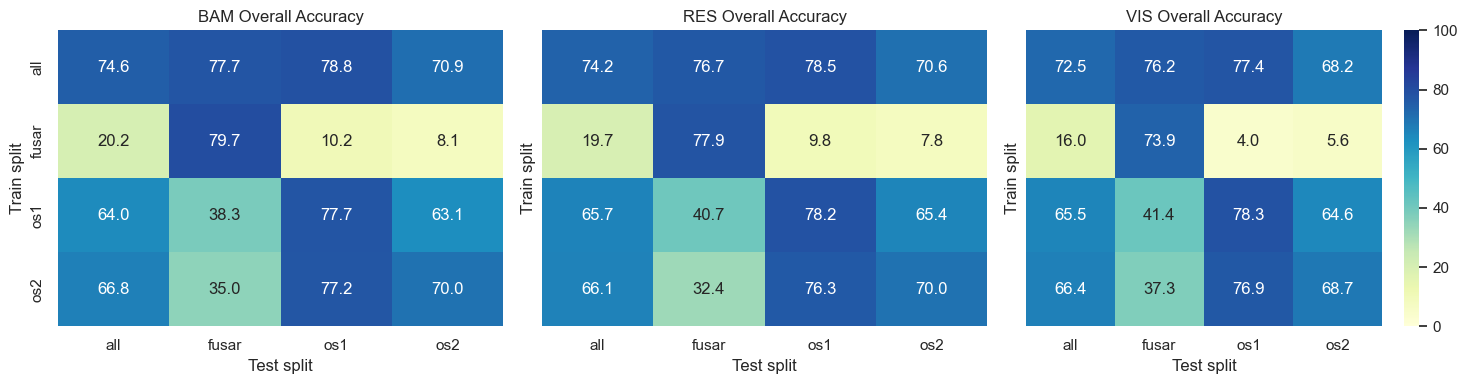

In [5]:
models = sorted(df_overall["model"].unique())
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4), sharey=True)

if len(models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, models):
    pivot = (
        df_overall[df_overall["model"] == model_name]
        .pivot(index="train_split", columns="test_split", values="overall_acc")
        .sort_index()
    )
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        cbar=ax is axes[-1],
        ax=ax,
        vmin=0,
        vmax=100,
    )
    ax.set_title(f"{model_name.upper()} Overall Accuracy")
    ax.set_xlabel("Test split")
    ax.set_ylabel("Train split")

plt.tight_layout()
plt.show()

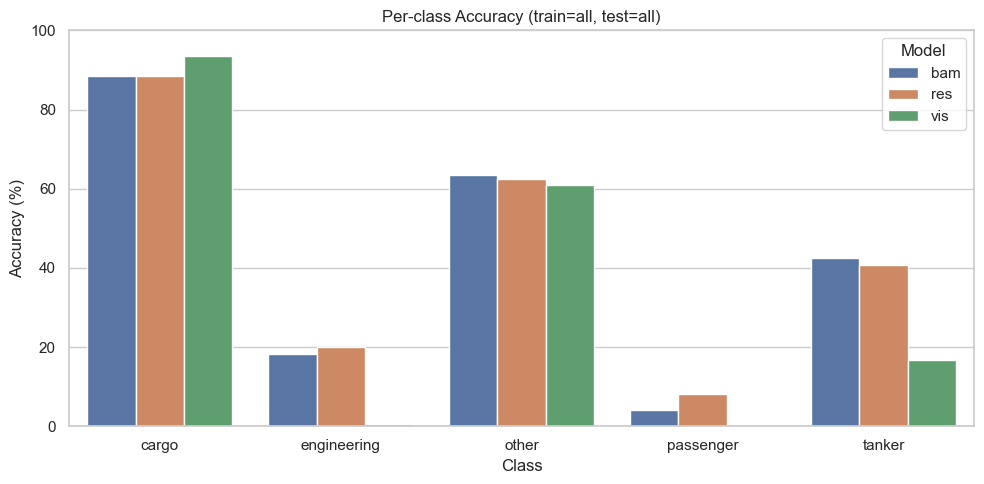

,model,train_split,test_split,class,acc,correct,total
235,vis,all,all,cargo,93.6471,3980,4250
75,bam,all,all,cargo,88.5647,3764,4250
155,res,all,all,cargo,88.4706,3760,4250
156,res,all,all,engineering,20.0000,35,175
76,bam,all,all,engineering,18.2857,32,175
236,vis,all,all,engineering,0.5714,1,175
77,bam,all,all,other,63.5046,482,759
157,res,all,all,other,62.4506,474,759
237,vis,all,all,other,61.0013,463,759
158,res,all,all,passenger,8.1633,4,49


In [6]:
focus = df_class[(df_class["train_split"] == "all") & (df_class["test_split"] == "all")].copy()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=focus,
    x="class",
    y="acc",
    hue="model",
    order=sorted(focus["class"].unique()),
)
plt.title("Per-class Accuracy (train=all, test=all)")
plt.xlabel("Class")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

focus.sort_values(["class", "acc"], ascending=[True, False]).head(15)

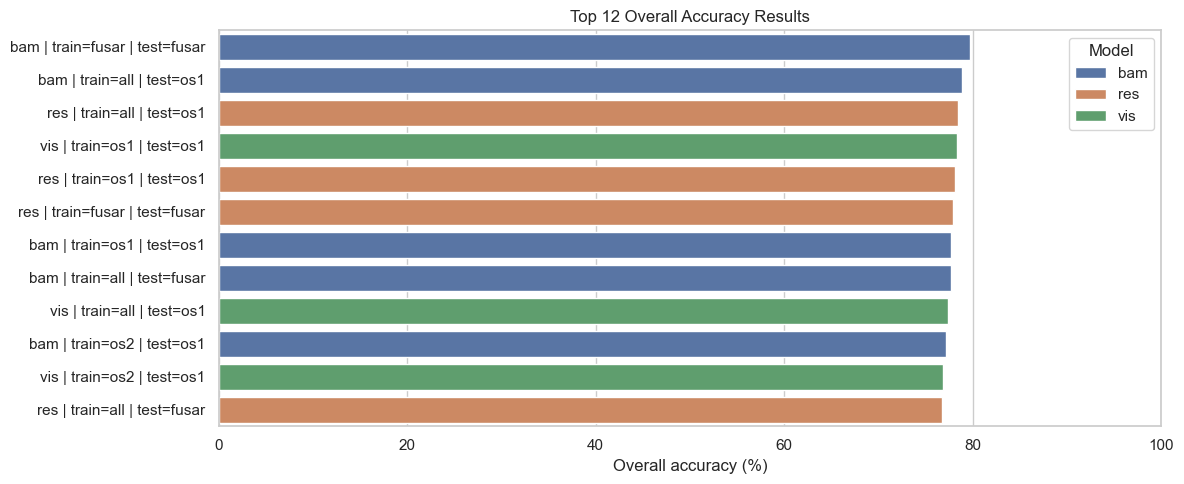

,model,train_split,test_split,overall_acc
10,bam,fusar,fusar,79.7258
12,bam,all,os1,78.8307
28,res,all,os1,78.4536
32,vis,os1,os1,78.3121
16,res,os1,os1,78.1707
26,res,fusar,fusar,77.8648
0,bam,os1,os1,77.6992
14,bam,all,fusar,77.6690
44,vis,all,os1,77.3692
4,bam,os2,os1,77.1806


In [7]:
top_overall = df_overall.sort_values("overall_acc", ascending=False).head(12)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=top_overall,
    x="overall_acc",
    y=top_overall.apply(
        lambda r: f"{r['model']} | train={r['train_split']} | test={r['test_split']}", axis=1
    ),
    hue="model",
    dodge=False,
)
plt.title("Top 12 Overall Accuracy Results")
plt.xlabel("Overall accuracy (%)")
plt.ylabel("")
plt.xlim(0, 100)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

top_overall

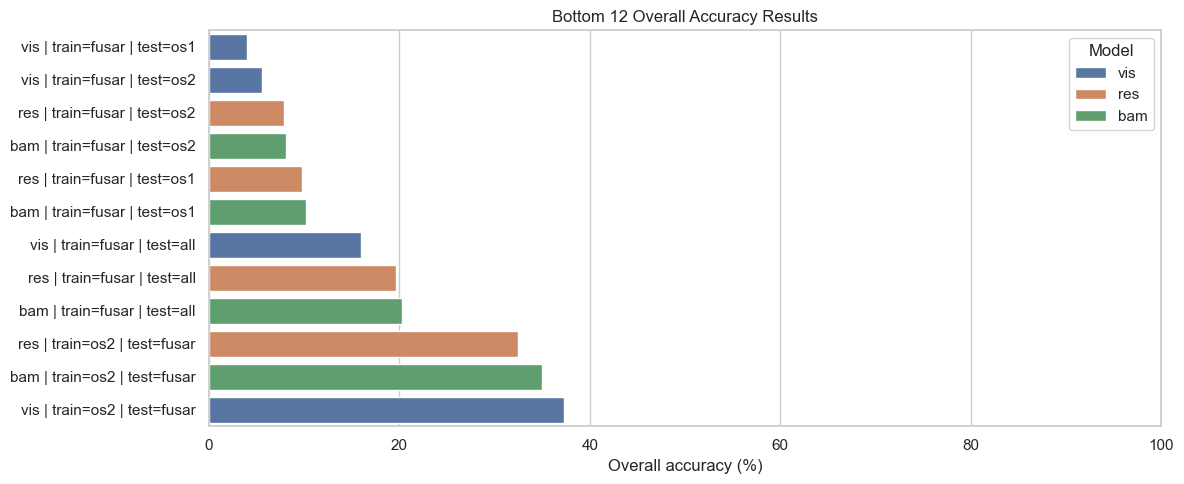

,model,train_split,test_split,overall_acc
40,vis,fusar,os1,3.9604
41,vis,fusar,os2,5.5897
25,res,fusar,os2,7.8317
9,bam,fusar,os2,8.1081
24,res,fusar,os1,9.8067
8,bam,fusar,os1,10.1839
43,vis,fusar,all,15.9581
27,res,fusar,all,19.6624
11,bam,fusar,all,20.2251
22,res,os2,fusar,32.4192


In [8]:
bottom_overall = df_overall.sort_values("overall_acc", ascending=True).head(12)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=bottom_overall,
    x="overall_acc",
    y=bottom_overall.apply(
        lambda r: f"{r['model']} | train={r['train_split']} | test={r['test_split']}", axis=1
    ),
    hue="model",
    dodge=False,
)
plt.title("Bottom 12 Overall Accuracy Results")
plt.xlabel("Overall accuracy (%)")
plt.ylabel("")
plt.xlim(0, 100)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

bottom_overall

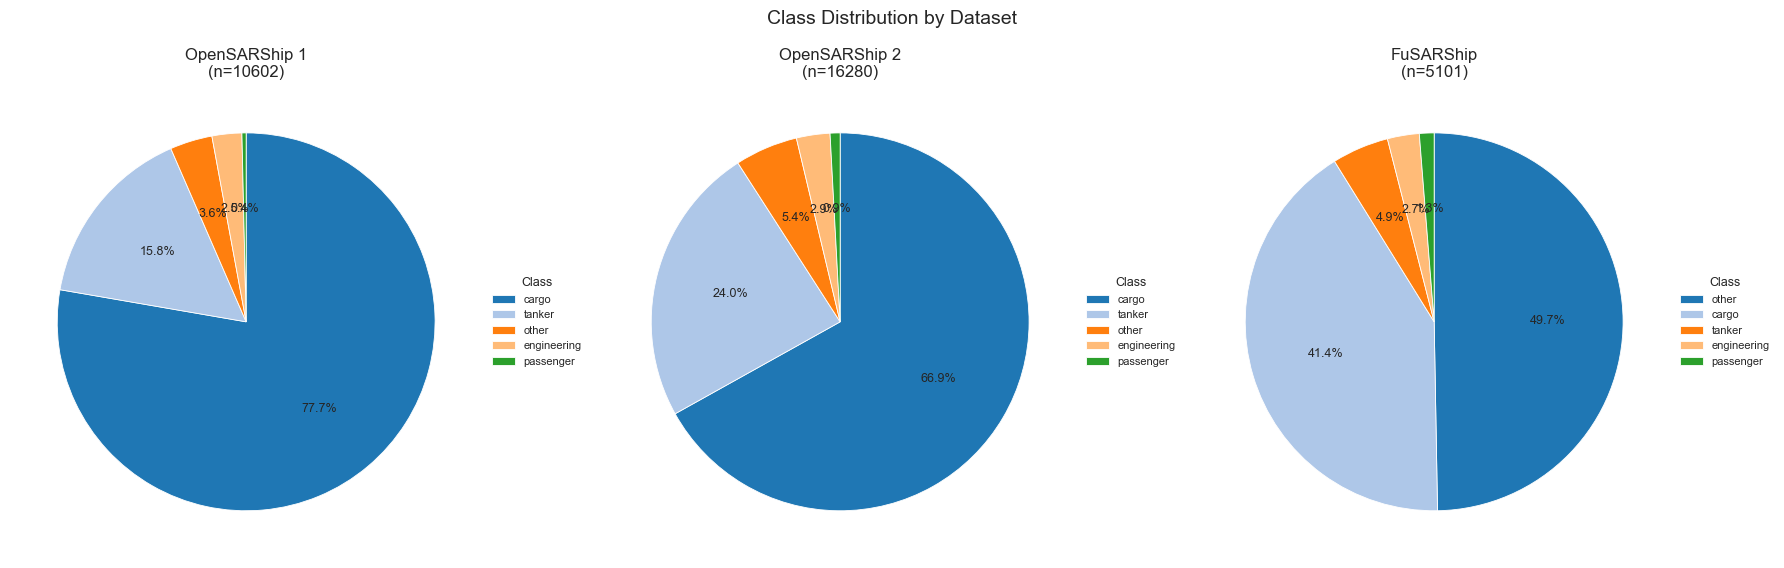

,os1_count,os2_count,fusar_count
label,,,
cargo,8240,10893,2114
tanker,1670,3905,248
other,384,876,2536
engineering,270,467,139
passenger,38,139,64


In [11]:
# Load dataset label files (same pattern used in src notebooks)
DATA_DIR = Path("data/classification/")

opensar1 = pd.read_csv(DATA_DIR / "opensar1_labels.csv")
opensar2 = pd.read_csv(DATA_DIR / "opensar2_labels.csv")
fusar = pd.read_csv(DATA_DIR / "fusar_labels.csv")

# Match baseline eval setup by removing unknown labels
for df in [opensar1, opensar2, fusar]:
    df.drop(df[df["label"] == "unknown"].index, inplace=True)

datasets = {
    "OpenSARShip 1": opensar1,
    "OpenSARShip 2": opensar2,
    "FuSARShip": fusar,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = sns.color_palette("tab20", n_colors=20)

for ax, (name, df) in zip(axes, datasets.items()):
    counts = df["label"].value_counts().sort_values(ascending=False)
    wedges, _, _ = ax.pie(
        counts.values,
        labels=None,
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False,
        colors=colors[: len(counts)],
        textprops={"fontsize": 9},
        wedgeprops={"edgecolor": "white", "linewidth": 0.6},
    )
    ax.legend(
        wedges,
        counts.index,
        title="Class",
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        fontsize=8,
        title_fontsize=9,
        frameon=False,
    )
    ax.set_title(f"{name}\n(n={len(df)})")

plt.suptitle("Class Distribution by Dataset", fontsize=14)
plt.tight_layout()
plt.show()

# Optional numeric table for exact class counts
dist_table = pd.concat(
    [
        opensar1["label"].value_counts().rename("os1_count"),
        opensar2["label"].value_counts().rename("os2_count"),
        fusar["label"].value_counts().rename("fusar_count"),
    ],
    axis=1,
).fillna(0).astype(int)

dist_table